In [28]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import eigh

import os
import pickle

from qiskit import transpile
from qiskit.circuit import ParameterVector
from qiskit.quantum_info import SparsePauliOp
from qiskit.quantum_info.operators import Operator
from qiskit_aer import AerSimulator
from qiskit.circuit import QuantumCircuit

from algo.utils_qiskit import find_pauli_indices
from utils import hamiltonian_to_matrix
from algo.utils_qiskit import process_hamiltonian_Zs
from algo.utils_qiskit import optimal_interp_points
from check_utils import interp_matrix

In [29]:
# num_q = 13 # N # IMPORTANT

# # Generate a random complex matrix
# A = np.random.rand(2**num_q, 2**num_q) + 1j * np.random.rand(2**num_q, 2**num_q)
# # Make it Hermitian
# Hmat = (A + A.conj().T) / 2

In [30]:
num_q = 4 # N # IMPORTANT 

# num_q = 6, layer = 8
# 4, 6, 8


Delta = 0.5 # g

# set H1
List_1 = []
op = "Z"
for k in range(num_q-2):
    op += "I"
op += "Z"
List_1.append(op)  
for i in range(num_q-1):
    op = ""
    for k in range(i):
        op += "I"
    op += "ZZ"
    for k in range(i+1,num_q-1):
        op += "I"
    List_1.append(op)

List_1.reverse()

H1 = SparsePauliOp(List_1, np.ones(num_q))  

# set H2
List_2 = []
for i in range(num_q):
    op = ""
    for k in range(i):
        op += "I"
    op += "X"
    for k in range(i+1,num_q):
        op += "I"
    List_2.append(op)
    
H2 = SparsePauliOp(List_2, Delta*np.ones(num_q))

# set H = H1 + H2
H = SparsePauliOp.sum([H1,H2])
Hmat = Operator(H)
Hmat = Hmat.data # This is the matrix representation of the Hamiltonian

# Print with detailed descriptions
print(f"Number of qubits (num_q): {num_q}")
print(f"Delta value: {Delta}")
print("List_1 (Pauli terms for XX interactions):")
print(List_1)
print("List_2 (Pauli terms for YY interactions):")
print(List_2)
print(H.size)
print(H)

Number of qubits (num_q): 4
Delta value: 0.5
List_1 (Pauli terms for XX interactions):
['IIZZ', 'IZZI', 'ZZII', 'ZIIZ']
List_2 (Pauli terms for YY interactions):
['XIII', 'IXII', 'IIXI', 'IIIX']
8
SparsePauliOp(['IIZZ', 'IZZI', 'ZZII', 'ZIIZ', 'XIII', 'IXII', 'IIXI', 'IIIX'],
              coeffs=[1. +0.j, 1. +0.j, 1. +0.j, 1. +0.j, 0.5+0.j, 0.5+0.j, 0.5+0.j, 0.5+0.j])


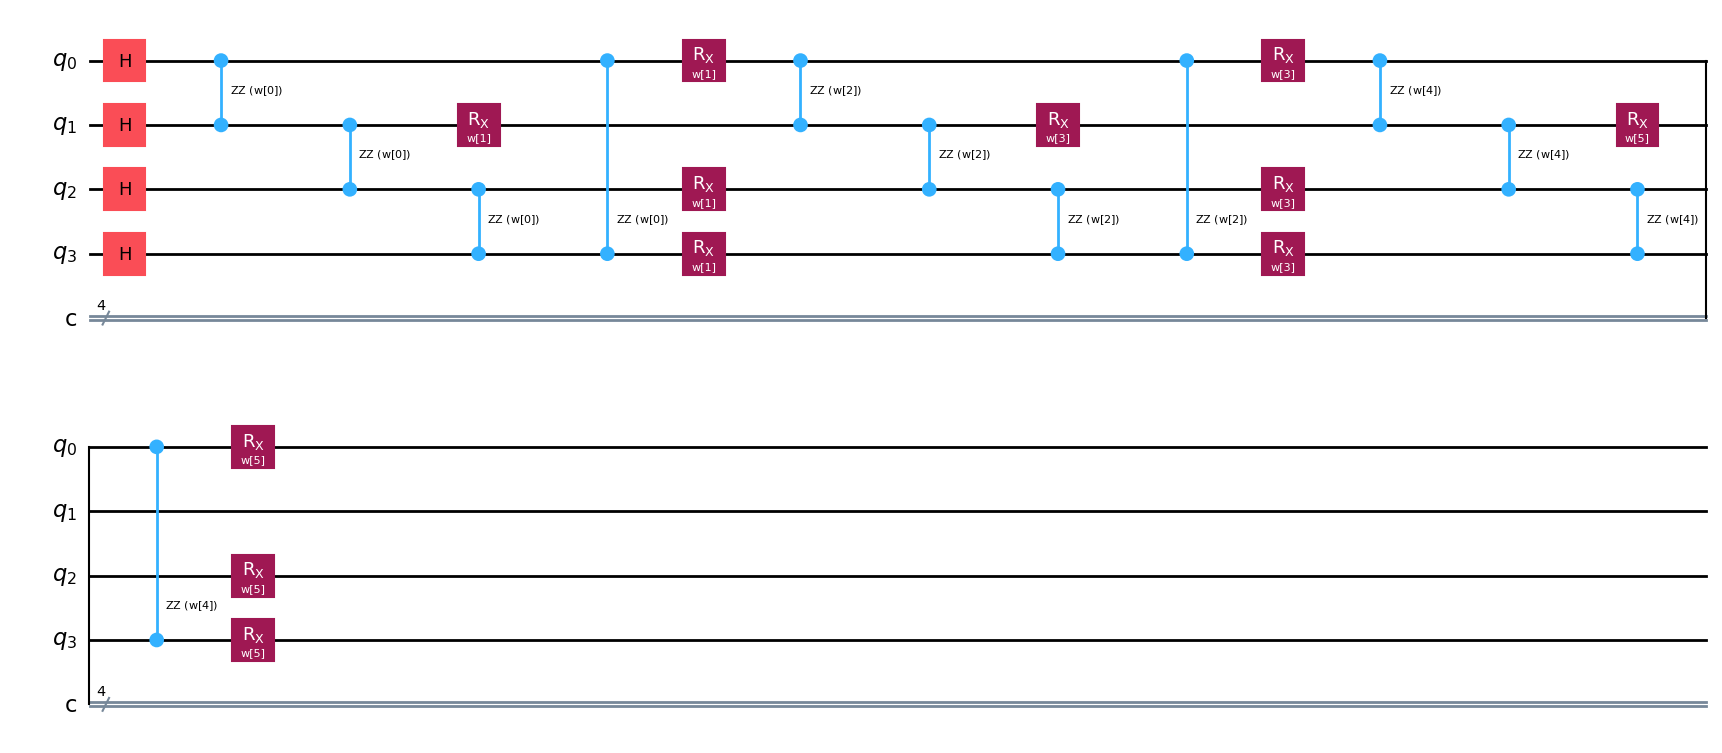

In [31]:
"""Circuit construction"""
layer = 3  # Define the number of layers in the quantum circuit

# This needs to be determined based on the circuit
num_p = layer * 2  # Calculate the number of parameters

weights = ParameterVector("w", num_p)  # Create a vector of parameters (parameters of the quantum circuit)

def circuit_HVA_TIFM(weights):
    circ = QuantumCircuit(num_q, num_q)

    for j in range(num_q):
        circ.h(j) 

    for i in range(layer):
        ## Odd layers
        for j in range(num_q):
            circ.rzz(weights[2 * i], j , (j + 1) % num_q)  ## ZZ gates in odd sum
            # weights  [0]
        for j in range(num_q):
            circ.rx(weights[2 * i + 1], j)  ## YY gates in odd sum
            # weights  [1]

    return circ 

qc = circuit_HVA_TIFM(weights)
# print(qc)
qc.draw("mpl")
# Latex drawing
# qc.draw(output="latex")


In [32]:
simulator = AerSimulator()


def expectation_loss(WEIGHTS):
    qc = circuit_HVA_TIFM(WEIGHTS)
    qc.save_statevector()
    qc = transpile(qc, simulator)
    result = simulator.run(qc).result()
    state_vector = result.get_statevector(qc)
    psi = np.asarray(state_vector)
    # ==========================================================================
    Hpsi = Hmat.dot(psi)
    expectation = np.inner(np.conjugate(psi),Hpsi)
    return np.real(expectation)


In [33]:
weights_dict = {}

#################### Odd layers with RZZ gates
omegas_1 = [2]
# omegas_1 = list(range(2, num_q + 1,2))
interp_nodes_1 = np.linspace(0, 2 * np.pi, 2 * len(omegas_1) + 1, endpoint=False)
inverse_interp_matrix_1 = np.linalg.inv(interp_matrix(interp_nodes_1, omegas_1))

#################### Even layers with RX gates
omegas_2 = [2]
# omegas_2 = list(range(2, num_q + 1,2))
interp_nodes_2 = np.linspace(0, 2 * np.pi, 2 * len(omegas_2) + 1, endpoint=False)
inverse_interp_matrix_2 = np.linalg.inv(interp_matrix(interp_nodes_2, omegas_2))

# Construct weights_dict
weights_dict = {}
for j in range(num_p): 
    if j % 2 == 0:  # Odd layers with RZZ gates
        weights_dict[f'weights_{j}'] = {
            'omegas': omegas_1,
            'scale_factor': 2.0,
            'interp_nodes': interp_nodes_1,
            'inverse_interp_matrix': inverse_interp_matrix_1,
        }
    elif j % 2 == 1:  # Even layers with RYY+RXX gates
        weights_dict[f'weights_{j}'] = {
            'omegas': omegas_2,
            'scale_factor': 2.0,
            'interp_nodes': interp_nodes_2,
            'inverse_interp_matrix': inverse_interp_matrix_2,
        }

# print(weights_dict['weights_0'])
# print(weights_dict['weights_1'])
# print(len(weights_dict))


In [34]:
# Verify if the function can be accurately interpolated by trigonometric interpolation based on omegas

from check_utils import check_is_trigometric  # Assuming check_is_trigometric is defined in check_utils module
from check_utils import filter_omegas  # Assuming check_is_trigometric is defined in check_utils module

# Define random weights
weights = np.random.normal(0, 4 * np.pi**2, num_p)

# Loop over each weight index and check trigonometric interpolation

TRUE_OMEGAS= []
for j in range(num_p):
    # Circuit_HEA is simple and all Hermitian generators are Y.
    omegas = weights_dict[f'weights_{j}']['omegas']  # This needs to be determined based on the circuit (i.e., parameters to test interpolation)
    
    print('\n index to check = ', j)
    print('omegas = ', omegas)
    
    opt_interp_flag = False  # Flag to indicate if optimal interpolation should be used
    
    # Call the function to check if the objective function can be interpolated using trigonometric interpolation
    estimated_coefficients = check_is_trigometric(expectation_loss, j, omegas, weights, opt_interp_flag)
    
    true_oemgeas = filter_omegas(estimated_coefficients, omegas, threshold=1e-7)

    print('true_oemgeas = ', true_oemgeas)
    TRUE_OMEGAS.append(true_oemgeas)


 index to check =  0
omegas =  [2]
Consistent results: 50/50
【All Passed】
Estimated coefficients:  [-2.15172225  0.18856681 -1.26511917]
true_oemgeas =  [2]

 index to check =  1
omegas =  [2]
Consistent results: 50/50
【All Passed】
Estimated coefficients:  [-1.58100475 -0.96977149  0.0824948 ]
true_oemgeas =  [2]

 index to check =  2
omegas =  [2]
Consistent results: 50/50
【All Passed】
Estimated coefficients:  [-1.42418469  2.02235027 -0.53580148]
true_oemgeas =  [2]

 index to check =  3
omegas =  [2]
Consistent results: 50/50
【All Passed】
Estimated coefficients:  [-0.51670613 -0.5330596   2.04385757]
true_oemgeas =  [2]

 index to check =  4
omegas =  [2]
Consistent results: 50/50
【All Passed】
Estimated coefficients:  [ 1.64420519 -2.46965743  0.58319227]
true_oemgeas =  [2]

 index to check =  5
omegas =  [2]
Consistent results: 50/50
【All Passed】
Estimated coefficients:  [-0.25794128  0.99068385  1.52026605]
true_oemgeas =  [2]


In [35]:
for i in range(len(TRUE_OMEGAS)):
    # print('index to check = ', i)
    print(TRUE_OMEGAS[i])

[2]
[2]
[2]
[2]
[2]
[2]


In [36]:
print(num_q)
print(layer)
print(num_p)

4
3
6
